# leveraging AVISO while gaussian filtering SWOT data

In [1]:
import xarray as xr
import pandas as pd
import numpy as np

import os
from glob import glob

import matplotlib.pyplot as plt

from numba import njit, prange
#, int32, float64

from cstes import zarr_dir, version_swot, swot_dir_2km


import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature



## numba code for gaussian filtering

In [2]:
@njit()
def _dist_geo(lon1, lat1, lon2, lat2):
    """Computes the Haversine distance in kilometres between two points
    :param x: first point or points as array, each as array of latitude, longitude in degrees
    :param y: second point or points as array, each as array of latitude, longitude in degrees
    :return: distance between the two points in kilometres
    """
    deg2rad = np.pi/180.
    llat1 = lat1 * deg2rad
    llat2 = lat2 * deg2rad
    llon1 = lon1 * deg2rad
    llon2 = lon2 * deg2rad
    arclen = 2 * np.arcsin(
        np.sqrt(
            (np.sin((llat2 - llat1) / 2)) ** 2
            + np.cos(llat1) * np.cos(llat2) * (np.sin((llon2 - llon1) / 2)) ** 2
        )
    )
    earth_radius = 6370e3  # approximate Earth radius at 40degN in meters
    # https://en.wikipedia.org/wiki/Earth_radius
    return arclen * earth_radius

@njit()
def _gauss2d(d, sigma):
    sigma2 = sigma**2
    d2 = d**2
    #return (0.5/np.pi/sigma2) * np.exp(-0.5/sigma2*d**2)
    return np.exp(-0.5*d2/sigma2) # shortcut expecting normalization down the line

@njit(parallel=True)
def nb_filter_gaussian(
    lon0, lat0, v0, mask0,
    sigma, truncate,
):
    """filter data with Gaussian filter"""
    vf = np.zeros_like(v0)
    weight0 = np.zeros_like(v0)
    n0 = len(vf)

    sigma_x_truncate = sigma*truncate
    
    for i0 in prange(n0):
        # loop over primary data points
        for j0 in range(n0):
            d = _dist_geo(lon0[i0], lat0[i0], lon0[j0], lat0[j0])
            if mask0[j0]>0 and d<sigma_x_truncate:
                w = _gauss2d(d, sigma)
                weight0[i0] += w
                vf[i0] += v0[j0]*w
        vf[i0] = vf[i0]/weight0[i0]

    return vf, weight0

@njit(parallel=True)
def nb_filter_gaussian_combined(
    lon0, lat0, v0, mask0,
    lon1, lat1, v1, 
    area_ratio,
    sigma, truncate,
):
    """filter data with Gaussian filter leveraging external data for points where the primary 
    data source has no nearby points"""
    vf = np.zeros_like(v0)
    weight0 = np.zeros_like(v0)
    weight1 = np.zeros_like(v0)
    n0 = len(vf)
    n1 = len(v1)

    sigma_x_truncate = sigma*truncate
    
    for i0 in prange(n0):
        # loop over primary data points
        for j0 in range(n0):
            d = _dist_geo(lon0[i0], lat0[i0], lon0[j0], lat0[j0])
            if mask0[j0]>0 and d<sigma_x_truncate:
                w = _gauss2d(d, sigma)
                weight0[i0] += w
                vf[i0] += v0[j0]*w
        # loop over secondary data points
        for i1 in range(n1):
            d = _dist_geo(lon0[i0], lat0[i0], lon1[i1], lat1[i1])
            if d<sigma_x_truncate:
                w = _gauss2d(d, sigma)*area_ratio
                weight1[i0] += w
                vf[i0] += v1[i1]*w
                    
        vf[i0] = vf[i0]/(weight0[i0]+weight1[i0])

    return vf, weight0, weight1

@njit(parallel=True)
def nb_mask_grid(lon, lat, lon1, lat1, dl):
    """ mask secondary data if close to primary one """
    n = len(lon)
    n1 = len(lon1)
    mask1 = np.ones_like(lon1)

    for i1 in prange(n1):
        for i in range(n):
            d = _dist_geo(lon[i], lat[i], lon1[i1], lat1[i1])
            if d<dl:
                mask1[i1]=0
                break

    return mask1

## load data

In [3]:
L4_dir = {'L4_noswot_regional' :'/home/ifremer-lops-cswot/DATA/DUACS/NOSWOT/duacs_dt2021/regional-europe/dt-grids/all-sat-merged/2023/*.nc', 
          'L4_noswot_global':'/home/ifremer-lops-cswot/DATA/DUACS/NOSWOT/duacs_dt2021/global/dt-grids/all-sat-merged/2023/*.nc', 
          'L4_withnadirswot' :'/home/ref-cmems-public/tac/sea-level/SEALEVEL_GLO_PHY_L4_MY_008_047/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_202411/2023/*/*.nc',
         }
L4_key = 'L4_withnadirswot'

In [98]:
swot = xr.open_zarr(swot_dir_2km, "3_538.zarr")
#swot = xr.open_zarr(swot_dir_2km, "16_538.zarr")

#correct SWOT product time
if version_swot == '2.0.1' : swot['time'] = (swot.time - np.timedelta64(946684800000000000, 'ns'))
swot = swot.where(swot["latitude_nadir"].compute()>36, drop=True)
swot = swot.where(swot.duacs_editing_flag==0)
define_eta(swot, mean_sla=False)
swot["adt"] = swot["duacs_mean_dynamic_topography"] + swot["duacs_ssha_karin_2_filtered"]


#aviso = xr.open_dataset( "dt_europe_allsat_phy_l4_20230601_20231013.nc")
aviso = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'L4_sealevel', L4_key+'.nc'))
# select only area where swath is ... adjust for swath 16
aviso = aviso.sel(longitude=slice(swot.longitude.min()-1,swot.longitude.max()+1), latitude=slice(swot.latitude.min()-1, swot.latitude.max()+1))
aviso = aviso.interp(time = swot.time.mean().compute().values)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/zarr.py:1103: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = open_dataset(


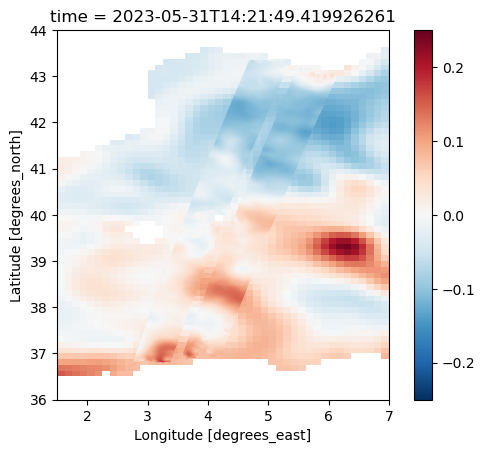

In [82]:
fig, ax = plt.subplots(1,1, frameon=False)
kw = dict(vmin=-.25, vmax=.25, cmap="RdBu_r")
#kw = dict(cmap="RdBu_r")
aviso["adt"].plot(add_colorbar=False, **kw)
im = ax.scatter(swot.longitude, swot.latitude, c=swot["adt"], s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im)

/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


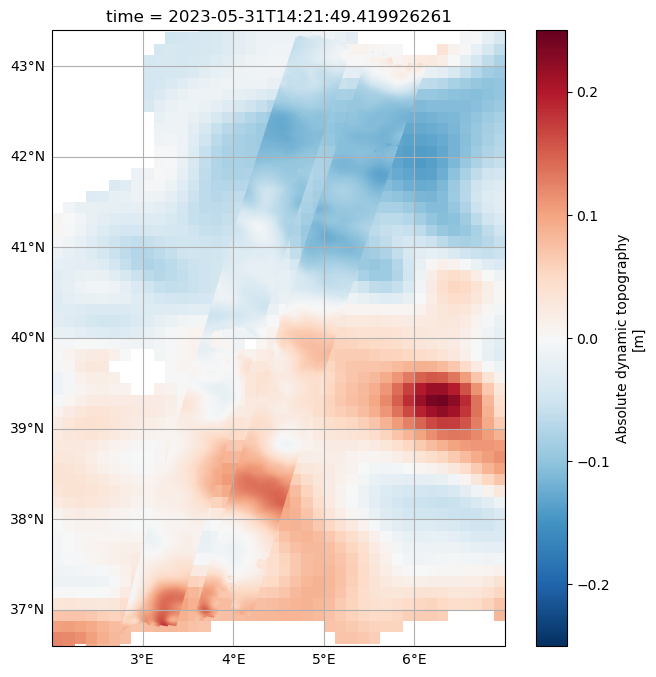

In [35]:
bbox = [2, 7, 36.6, 43.4]

fig = plt.figure(figsize=(8,8), frameon=False)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu_r",transform =crs,)
#kw = dict(cmap="RdBu_r")
aviso["adt"].assign_attrs({'longname': 'DSL [m]'}).plot( **kw,)
im = ax.scatter(swot.longitude, swot.latitude, c=swot["adt"], s=1, **kw,)
#ax.set_aspect(np.cos(np.deg2rad(40)))

ax.set_extent(bbox)
gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False


---
## dev/tests

In [25]:
# extract variables from aviso
ds = aviso.squeeze().stack(point=["longitude", "latitude"])
lon1 = ds.longitude.data
lat1 = ds.latitude.data
v1 = ds.adt.data

aviso_stacked = ds

In [26]:
# extract variables from swot
key = "adt"
ds = swot[["longitude", "latitude"]+[key]].stack(point=["num_lines", "num_pixels"]).compute()
mask = xr.where(
    (~np.isnan(ds.longitude)) 
    & (~np.isnan(ds.latitude))
    & (~np.isnan(ds[key])), 
    1, 0,
)
ds["mask"] = mask
swot_stacked = ds

ds =  ds.where(mask).fillna(0.)
lon = ds.longitude.data
lat = ds.latitude.data
v = ds[key].data
mask = mask.data

### dev mask building

In [27]:
%%time
# 20s on laptop with unsmoothed data, only has to be performed once though
# 1s with 2km data

#dl = 250. # m, unsmoothed data
dl = 2e3 # m
mask1 = nb_mask_grid(lon, lat, lon1, lat1, dl)

CPU times: user 6.13 s, sys: 24 ms, total: 6.15 s
Wall time: 1.32 s


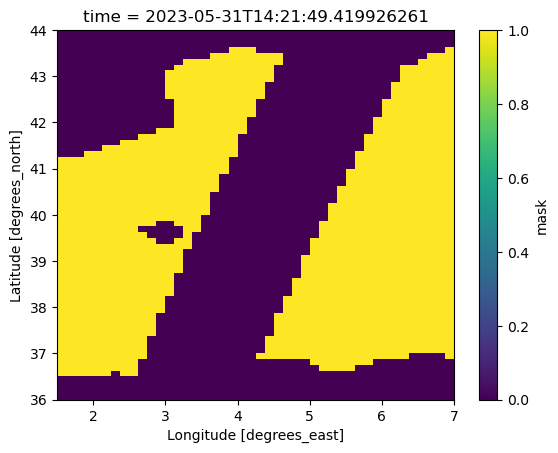

In [28]:
aviso_stacked["mask0"] = ~np.isnan(aviso_stacked["adt"])
aviso_stacked["mask1"] = ("point", mask1)
aviso_stacked["mask"] = aviso_stacked["mask0"] * aviso_stacked["mask1"]
aviso_stacked["mask"].unstack().plot(x="longitude")

In [29]:
# subsample secondary (aviso) data
ds = aviso_stacked.where( aviso_stacked.mask>0, drop=True)
lon1 = ds.longitude.data
lat1 = ds.latitude.data
v1 = ds.adt.data

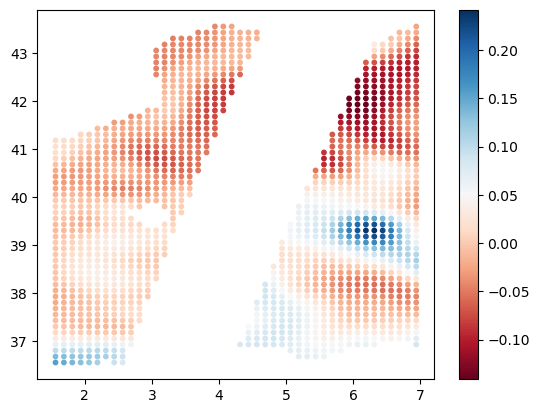

In [30]:
fig, ax = plt.subplots(1,1)
im = ax.scatter(lon1, lat1, c=v1, s=10, cmap="RdBu")
plt.colorbar(im)

In [31]:
dlon = float(aviso.longitude.diff("longitude").median())
dlat = float(aviso.latitude.diff("latitude").median())
_lat = float(aviso.latitude.median())
unit_area_aviso = float(dlon*np.cos(np.deg2rad(_lat))*dlat *(111e3)**2)

unit_area_swot = dl**2
area_ratio = unit_area_aviso/unit_area_swot
print(f"weight of aviso points vs swot points = {area_ratio:.1f}")

weight of aviso points vs swot points = 36.9


In [36]:
%%time

# 1.68s with 2km data

sigma = 40e3
truncate = 4.
area_ratio = unit_area_aviso/unit_area_swot
#area_ratio = 0.

vf, weight0, weight1 = nb_filter_gaussian_combined(
    lon, lat, v, mask,
    lon1, lat1, v1, 
    area_ratio,
    sigma, truncate,
)

swot_stacked["vf"] = ("point", vf)
swot_stacked["weight0"] = ("point", weight0)
swot_stacked["weight1"] = ("point", weight1)

# remask data
swot_stacked["vf"] = swot_stacked["vf"].where( swot_stacked["mask"] )

_swot = swot_stacked.unstack()

CPU times: user 1min 31s, sys: 8 ms, total: 1min 31s
Wall time: 1.75 s


(36.5, 43.5)

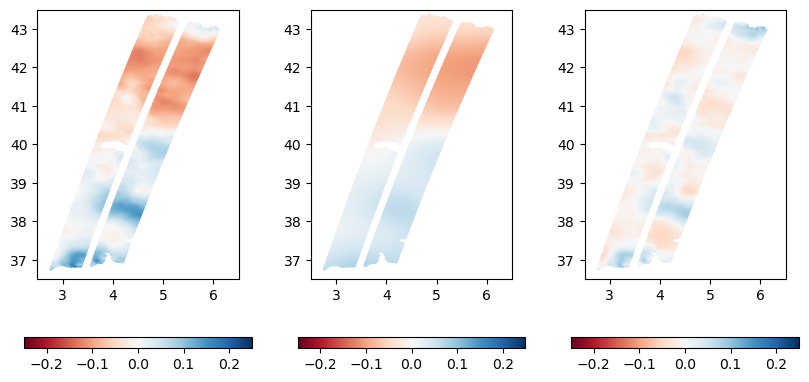

In [37]:

fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = _swot.adt
ax = axes[0]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = _swot.vf
ax = axes[1]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = _swot.adt - _swot.vf
ax = axes[2]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

Text(0.5, 1.0, 'cumulated weight aviso')

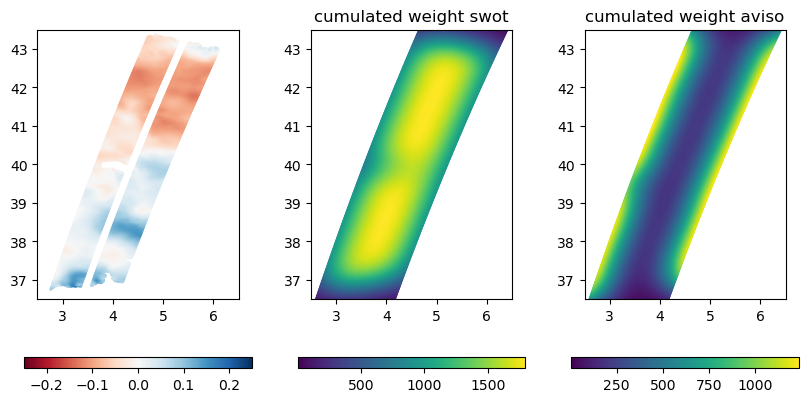

In [38]:
fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = _swot.adt
ax = axes[0]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = _swot["weight0"]
ax = axes[1]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("cumulated weight swot")

da = _swot["weight1"]
ax = axes[2]
im = ax.scatter(_swot.longitude, _swot.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("cumulated weight aviso")

---
# wrapped methods and example

In [199]:

# original script
def apply_gaussian_filter(swot_image, cutoff, mask, dx, dy):
    """
    Filter swot_image with a gaussian filter
    input : 
        swot_image : 2D array, image swot
        cutoff :  float, cutoff length (width at mid height of the gaussian filter)
        mask : 2D array with 0 out of swot swath and 1 within
        dx : float, x direction time step
        dy : float, y direction time step - not used here ...?
    """
    from scipy.ndimage import convolve1d
    import scipy.signal.windows as wdw
    
    # Gaussian a la mano
    lambda_cutoff = cutoff/dx
    sigma_cutoff = lambda_cutoff * np.sqrt(np.log(2))
    Mg = int(2 * np.round(4*lambda_cutoff)+1)
    gaussian = wdw.gaussian(Mg, std = sigma_cutoff)
    fg = xr.DataArray(convolve1d(convolve1d(swot_image.fillna(0), gaussian, axis=0), gaussian, axis=1), dims=swot_image.dims)#unnromalized
    fm = xr.DataArray(convolve1d(convolve1d(mask, gaussian, axis=0), gaussian, axis=1), dims=mask.dims)#unnormalized
    return xr.DataArray(fg/fm, dims=swot_image.dims)#normalized


def apply_gaussian_filter_nb(
    swot_image, cutoff, mask, dx, 
):
    """
    Filter swot_image with a gaussian filter with numba
    input : 
        swot_image : 2D array, image swot
        cutoff :  float, cutoff length (width at mid height of the gaussian filter) in m
        mask : 2D array with 0 out of swot swath and 1 within
        dx : float, x direction grid step in m
    """
    
    # try being consistent with Margot's initial choice
    sigma = cutoff * np.sqrt(np.log(2))
    truncate = 4.*cutoff/sigma

    # stack fields
    ds = (
        xr.merge([swot_image.rename("v"), mask.rename("mask")])
        .stack(point=["num_lines", "num_pixels"])
    )
    swot_stacked = ds
    ds =  ds.where(ds["mask"]).fillna(0.)
    lon0 = ds["longitude"].data
    lat0 = ds["latitude"].data
    v0 = ds["v"].data
    mask0 = ds["mask"].data

    # filter
    vf, weight0 = nb_filter_gaussian(
        lon0, lat0, v0, mask0,
        sigma, truncate,
    )
    swot_stacked["vf"] = ("point", vf)
    swot_stacked = swot_stacked.assign_coords(
        weight0=("point", weight0),
    )
    
    return swot_stacked["vf"].unstack()


def apply_gaussian_filter_aviso(
    swot_image, cutoff, mask, dx,
    aviso_image,
):
    """
    Filter swot_image with a gaussian filter and aviso outside tracks
    input : 
        swot_image : 2D array, image swot
        cutoff :  float, cutoff length (width at mid height of the gaussian filter) in m
        mask : 2D array with 0 out of swot swath and 1 within
        dx : float, x direction grid step in m
        aviso_image: xr.DataArray
    """
    
    # try being consistent with Margot's initial choice
    sigma = cutoff * np.sqrt(np.log(2))
    truncate = 4.*cutoff/sigma

    # compute relative weights
    dlon = float(aviso_image.longitude.diff("longitude").median())
    dlat = float(aviso_image.latitude.diff("latitude").median())
    _lat = float(aviso_image.latitude.median())
    unit_area_aviso = float(dlon*np.cos(np.deg2rad(_lat))*dlat *(111e3)**2)
    
    unit_area_swot = dx**2
    area_ratio = unit_area_aviso/unit_area_swot
    
    # stack swot fields
    ds = (
        xr.merge([swot_image.rename("v"), mask.rename("mask")])
        .stack(point=["num_lines", "num_pixels"])
    )
    swot_stacked = ds
    ds =  ds.where(ds["mask"]).fillna(0.)
    lon0, lat0 = ds["longitude"].data, ds["latitude"].data
    v0 = ds["v"].data
    mask0 = ds["mask"].data

    # mask and stack aviso fields    
    da = aviso_image.squeeze().stack(point=["longitude", "latitude"])
    lon1, lat1 = da.longitude.data, da.latitude.data
    da = da.assign_coords(
        mask0=xr.where(np.isnan(da), 0, 1),
        mask1=("point", nb_mask_grid(lon0, lat0, lon1, lat1, dx)),
    )
    da = da.where( (da.mask0*da.mask1)>0, drop=True)
    lon1, lat1 = da.longitude.data, da.latitude.data
    v1 = da.data
    
    # filter
    vf, weight0, weight1 = nb_filter_gaussian_combined(
        lon0, lat0, v0, mask0,
        lon1, lat1, v1, 
        area_ratio,
        sigma, truncate,
    )
    swot_stacked["vf"] = ("point", vf)
    swot_stacked = swot_stacked.assign_coords(
        weight0=("point", weight0),
        weight1=("point", weight1),
    )
    
    return swot_stacked["vf"].unstack()


def filter_diff_one(f, filter_diff_method = 'gaussian', filter_diff_kwargs = {'cutoff': 5e3}, mean_sla=False, distance_to_coast_min=None):
    """
    Filter or differenciate a SWOT image with one of the previous functions.
    input : 
        f : str, file containing SWOT image (netcdf)
        filter_diff_method : str, should be among: 'gaussian' (calls apply_gaussian_filter), 'fitting_kernel' (calls apply_fitting_kernel), 'diff_only' (call apply_stencil_diff) or xarray_diff (use xarray differentiate function)
        filter_diff_kwargs : dict, arguments of the chosen filter_diff_method
        mean_sla : boolean, if True, remove the mean SSH from the DSL
        distance_to_coast_min : select only points at more than XX km from the coast

    """
    ds = xr.open_dataset(f)
    #correct SWOT product time
    if version_swot == '2.0.1' : ds['time'] = (ds.time - np.timedelta64(946684800000000000, 'ns'))
        
    define_eta(ds, mean_sla)
    ds = add_grid_metrics(ds)
    dx = np.round(float(ds.dx.mean()))
    dy = np.round(float(ds.dy.mean()))
    print(dx, dy)
    
    if distance_to_coast_min != None:
        ds = ds.where(ds.distance_to_coast>distance_to_coast_min, drop=True)

    vars_ = [v for v in list(ds.keys()) if ('etaf' in v)|('etac' in v)]+['duacs_editing_flag', 'longitude', 'latitude']
    
    ds =ds.drop_vars(['latitude_nadir','longitude_nadir','dx','phi','dy'])[vars_]
    
    if filter_diff_method == 'fitting_kernel':
        ds = ds.interpolate_na('num_pixels').interpolate_na('num_lines') # erreur dans l'entre-fauchée pour gaussian filter but ok for fitting kernel
    #mask = ds.duacs_editing_flag.where(ds.duacs_editing_flag!=0,1).where(ds.duacs_editing_flag==0,0)
    mask = xr.where((~np.isnan(ds.longitude)) & (~np.isnan(ds.latitude))& (~np.isnan(ds['etaf'])),1, 0)
    
    try : 
        D = []
        for eta in [v for v in list(ds.keys()) if ('etaf' in v)|('etac' in v)] :
            swot_image = ds[eta]
            #gaussian method (old version apply 2 1D gaussian filter succesively)
            if filter_diff_method == 'gaussian_2times1D' :
                assert list(filter_diff_kwargs.keys()) == ['cutoff'], 'The gaussian method needs one argument cutoff (gaussian x at H/2)'
                output = apply_gaussian_filter(swot_image,  **filter_diff_kwargs, mask = mask, dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()

                #stencil diff
                #for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                #   output[var + '_'+eta] = apply_stencil_diff(output['filtered_'+eta], var, dx=dx, dy=dy)
                
                # xarray diff
                output['dx_'+eta] = output['filtered_'+eta].differentiate('num_pixels')/dx
                output['dy_'+eta] = output['filtered_'+eta].differentiate('num_lines')/dy
                output['dxx_'+eta] = output['dx_'+eta].differentiate('num_pixels')/dx
                output['dyy_'+eta] = output['dy_'+eta].differentiate('num_lines')/dy
                output['dxy_'+eta] = output['dx_'+eta].differentiate('num_lines')/dy
                D.append(output)
            
            #gaussian method using aviso at the edge
            elif filter_diff_method == 'gaussian_aviso' :
                assert list(filter_diff_kwargs.keys()) == ['cutoff'], 'The gaussian method needs one argument cutoff (gaussian x at H/2)'
                
                #AVISO
                aviso = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'L4_sealevel', L4_key+'.nc'))
                # select only area where swath is ... adjust for swath 16
                aviso = aviso.sel(longitude=slice(ds.longitude.min()-1,ds.longitude.max()+1), latitude=slice(ds.latitude.min()-1, swot.latitude.max()+1))
                aviso = aviso.interp(time = ds.time.mean().compute().values)
                aviso = aviso['adt']
                #return swot_image, mask, dx, aviso

                output = apply_gaussian_filter_aviso(swot_image, **filter_diff_kwargs, mask = mask, dx = dx, aviso_image = aviso).rename('filtered_'+eta).to_dataset()

                #stencil diff
                #for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                #   output[var + '_'+eta] = apply_stencil_diff(output['filtered_'+eta], var, dx=dx, dy=dy)
                
                # xarray diff
                output['dx_'+eta] = output['filtered_'+eta].differentiate('num_pixels')/dx
                output['dy_'+eta] = output['filtered_'+eta].differentiate('num_lines')/dy
                output['dxx_'+eta] = output['dx_'+eta].differentiate('num_pixels')/dx
                output['dyy_'+eta] = output['dy_'+eta].differentiate('num_lines')/dy
                output['dxy_'+eta] = output['dx_'+eta].differentiate('num_lines')/dy
                D.append(output)

        
            #gaussian method with 2D filter (version 'a la mano' with numba by aurelien)
            elif filter_diff_method == 'gaussian_aviso' :
                assert list(filter_diff_kwargs.keys()) == ['cutoff'], 'The gaussian method needs one argument cutoff (gaussian x at H/2)'
                
                #AVISO
                aviso = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'L4_sealevel', L4_key+'.nc'))
                # select only area where swath is ... adjust for swath 16
                aviso = aviso.sel(longitude=slice(ds.longitude.min()-1,ds.longitude.max()+1), latitude=slice(ds.latitude.min()-1, swot.latitude.max()+1))
                aviso = aviso.interp(time = ds.time.mean().compute().values)
                aviso = aviso['adt']
                #return swot_image, mask, dx, aviso

                output = apply_gaussian_filter_nb(swot_image, **filter_diff_kwargs, mask = mask, dx = dx).rename('filtered_'+eta).to_dataset()

                #stencil diff
                #for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                #   output[var + '_'+eta] = apply_stencil_diff(output['filtered_'+eta], var, dx=dx, dy=dy)
                
                # xarray diff
                output['dx_'+eta] = output['filtered_'+eta].differentiate('num_pixels')/dx
                output['dy_'+eta] = output['filtered_'+eta].differentiate('num_lines')/dy
                output['dxx_'+eta] = output['dx_'+eta].differentiate('num_pixels')/dx
                output['dyy_'+eta] = output['dy_'+eta].differentiate('num_lines')/dy
                output['dxy_'+eta] = output['dx_'+eta].differentiate('num_lines')/dy
                D.append(output)
            
            # Fitting kernel method
            elif filter_diff_method == 'fitting_kernel' :
                assert list(filter_diff_kwargs.keys()) == ['npts'], 'The fitting kernel method needs one argument npts (odd, kernel = [npts, npts])'
                output = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var = 'cste', dx=dx, dy=dy).rename('filtered_'+eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_fitting_kernel(swot_image, **filter_diff_kwargs, var=var, dx=dx, dy=dy)
                D.append(output)

            #diff only method
            elif filter_diff_method == 'diff_only' :
                output = swot_image.rename(eta).to_dataset()
                for var in ['dx', 'dy', 'dxx', 'dyy', 'dxy'] : 
                    output[var + '_'+eta] = apply_stencil_diff(swot_image, var, dx=dx, dy=dy)
                D.append(output)
                
            # xarray simple diff
            elif filter_diff_method == 'xarray_diff' :
                output = swot_image.rename(eta).to_dataset()
                output['dx_'+eta] = output[eta].differentiate('num_pixels')/dx
                output['dy_'+eta] = output[eta].differentiate('num_lines')/dy
                output['dxx_'+eta] = output['dx_'+eta].differentiate('num_pixels')/dx
                output['dyy_'+eta] = output['dy_'+eta].differentiate('num_lines')/dy
                output['dxy_'+eta] = output['dx_'+eta].differentiate('num_lines')/dy
                D.append(output)
                    
    except: 
        assert False, f
    return xr.merge(D + [ds[['longitude', 'latitude']]]).where(ds.duacs_editing_flag==0)

In [202]:
cutoff = 20e3

# Using wrapper
from altimetry_filter import define_eta, add_grid_metrics
f = os.path.join(swot_dir_2km, "3_538.zarr")
d =  filter_diff_one(f, filter_diff_method = 'gaussian_aviso', filter_diff_kwargs = {'cutoff': cutoff}, mean_sla=False, distance_to_coast_min=None)

# with function
swot = xr.open_zarr(swot_dir_2km, "3_538.zarr")

#correct SWOT product time
if version_swot == '2.0.1' : swot['time'] = (swot.time - np.timedelta64(946684800000000000, 'ns'))
#swot = swot.where(swot["latitude_nadir"].compute()>36, drop=True)
swot = swot.where(swot.duacs_editing_flag==0)
define_eta(swot, mean_sla=False)
swot["adt"] = swot["duacs_mean_dynamic_topography"] + swot["duacs_ssha_karin_2_filtered"]
dl=2000
aviso = xr.open_dataset(os.path.join(zarr_dir, 'before_coloc', 'L4_sealevel', L4_key+'.nc'))
# select only area where swath is ... adjust for swath 16
aviso = aviso.sel(longitude=slice(swot.longitude.min()-1,swot.longitude.max()+1), latitude=slice(swot.latitude.min()-1, swot.latitude.max()+1))
aviso = aviso.interp(time = swot.time.mean().compute().values)
swot = swot.compute()
swot["mask"] = xr.where(
    (~np.isnan(swot.longitude)) 
    & (~np.isnan(swot.latitude))
    & (~np.isnan(swot.adt)),
    1, 0,
)

daf = apply_gaussian_filter_nb(swot["etaf"], cutoff, swot["mask"], dl)
daf_aviso = apply_gaussian_filter_aviso(swot["etaf"], cutoff, swot["mask"], dl, aviso["adt"])



/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'netcdf4' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


2000.0 2000.0


/home1/datahome/mdemol/.miniconda3/envs/histenv/lib/python3.9/site-packages/xarray/backends/zarr.py:1103: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = open_dataset(


## Check same with filter_diff_one

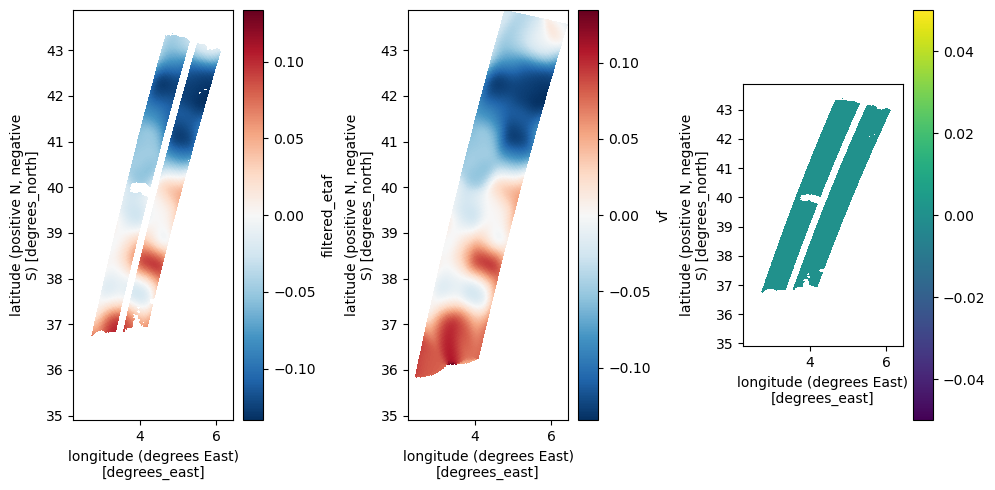

In [207]:
fig, axs = plt.subplots(1,3, figsize =(10, 5))
ax=axs[0]
d.filtered_etaf.plot(x='longitude', y='latitude', ax=ax)
ax=axs[1]
daf_aviso.plot(x='longitude', y='latitude',ax=ax)
ax=axs[2]
(d.filtered_etaf- daf_aviso).plot(x='longitude', y='latitude',ax=ax)
ax.set_aspect(np.cos(np.deg2rad(40)))
fig.tight_layout()

In [43]:
swot = swot[["adt"]].compute()

swot["mask"] = xr.where(
    (~np.isnan(swot.longitude)) 
    & (~np.isnan(swot.latitude))
    & (~np.isnan(swot.adt)),
    1, 0,
)

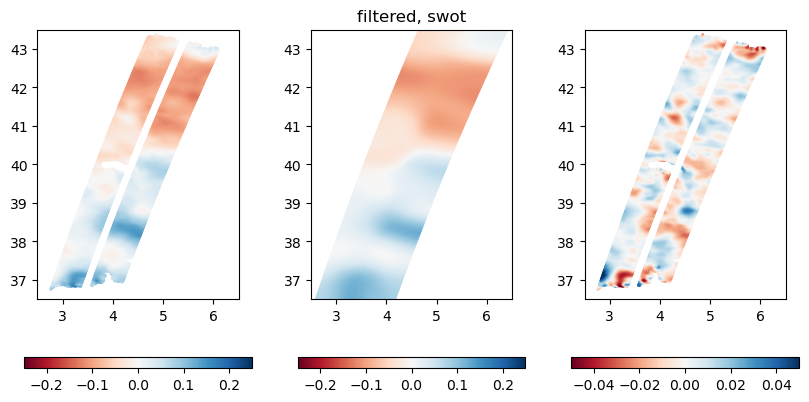

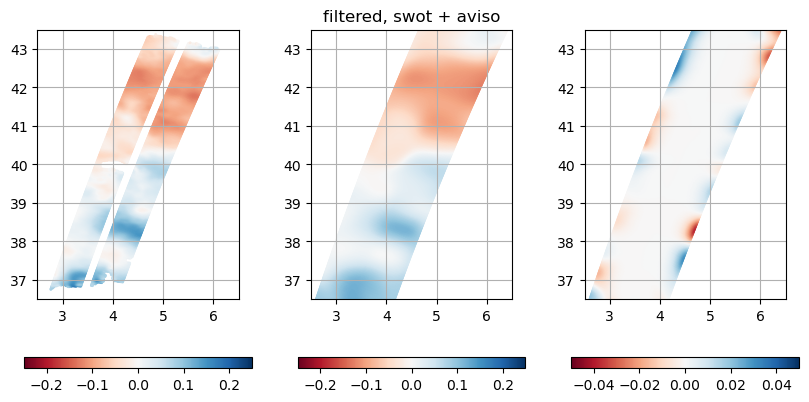

In [52]:
cutoff = 20e3
daf = apply_gaussian_filter_nb(swot["adt"], cutoff, swot["mask"], dl)
daf_aviso = apply_gaussian_filter_aviso(swot["adt"], cutoff, swot["mask"], dl, aviso["adt"])


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = daf
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("filtered, swot")

da = daf - swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
#da = swot["mask"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf_aviso
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()
ax.set_title("filtered, swot + aviso")

da = daf_aviso -daf# swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()



In [54]:
daf

<xarray.DataArray 'vf' (num_lines: 441, num_pixels: 69)> Size: 243kB
array([[ 0.0835345 ,  0.08354544,  0.08355647, ...,         nan,
                nan,         nan],
       [ 0.08299359,  0.08300392,  0.08301436, ...,         nan,
                nan,         nan],
       [ 0.082105  ,  0.0821082 ,  0.08211136, ...,         nan,
                nan,         nan],
       ...,
       [-0.04365815, -0.04316203, -0.04265052, ...,  0.02142632,
         0.02167931,  0.02184999],
       [-0.04340266, -0.04291574, -0.04241511, ...,  0.02192631,
         0.02217272,  0.02237255],
       [-0.04314649, -0.04266918, -0.04217935, ...,  0.02250998,
         0.02278421,  0.02299332]])
Coordinates:
  * num_lines        (num_lines) int64 4kB 0 1 2 3 4 5 ... 436 437 438 439 440
  * num_pixels       (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 63 64 65 66 67 68
    latitude         (num_lines, num_pixels) float64 243kB 36.13 36.13 ... 43.57
    latitude_nadir   (num_lines, num_pixels) float64 243kB 36.01 36.01 ... 43.72
    longitude        (num_lines, num_pixels) float64 243kB 2.514 2.536 ... 6.423
    longitude_nadir  (num_lines, num_pixels) float64 243kB 3.242 3.242 ... 5.596
    time             (num_lines, num_pixels) datetime64[ns] 243kB 2023-05-31T...
    weight0          (num_lines, num_pixels) float64 243kB 0.0001955 ... 0.00...

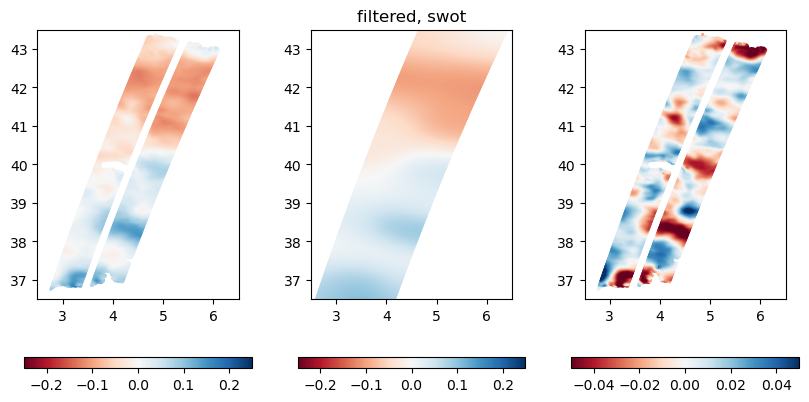

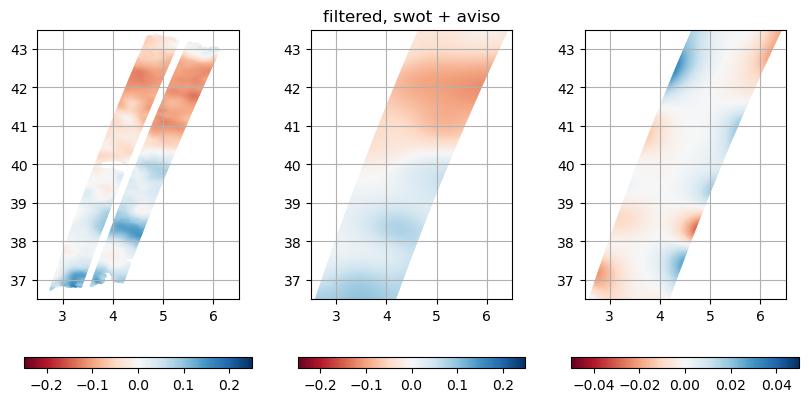

In [50]:
cutoff = 40e3
daf = apply_gaussian_filter_nb(swot["adt"], cutoff, swot["mask"], dl)
daf_aviso = apply_gaussian_filter_aviso(swot["adt"], cutoff, swot["mask"], dl, aviso["adt"])


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = daf
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("filtered, swot")

da = daf - swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
#da = swot["mask"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf_aviso
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()
ax.set_title("filtered, swot + aviso")

da = daf_aviso - daf#swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

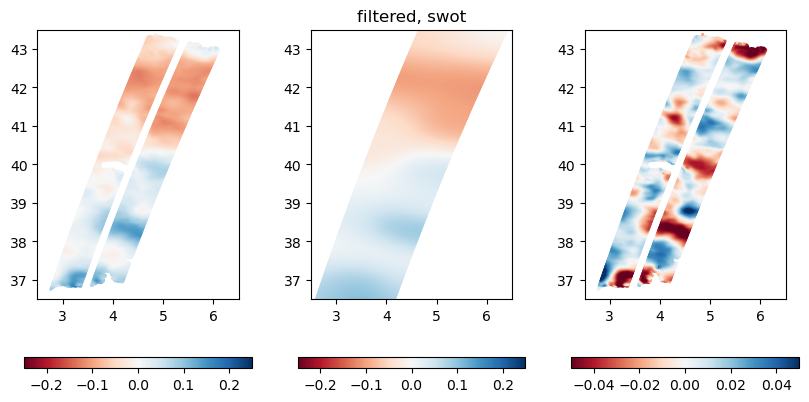

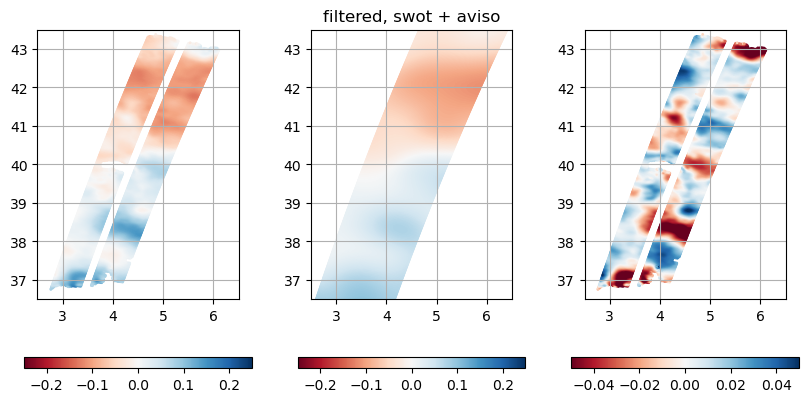

In [49]:
cutoff = 40e3
daf = apply_gaussian_filter_nb(swot["adt"], cutoff, swot["mask"], dl)
daf_aviso = apply_gaussian_filter_aviso(swot["adt"], cutoff, swot["mask"], dl, aviso["adt"])


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)

da = daf
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.set_title("filtered, swot")

da = daf - swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)


fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["adt"]
#da = swot["mask"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf_aviso
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, **kw)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()
ax.set_title("filtered, swot + aviso")

da = daf_aviso - swot["adt"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1, vmin=-.05, vmax=.05, cmap="RdBu")
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

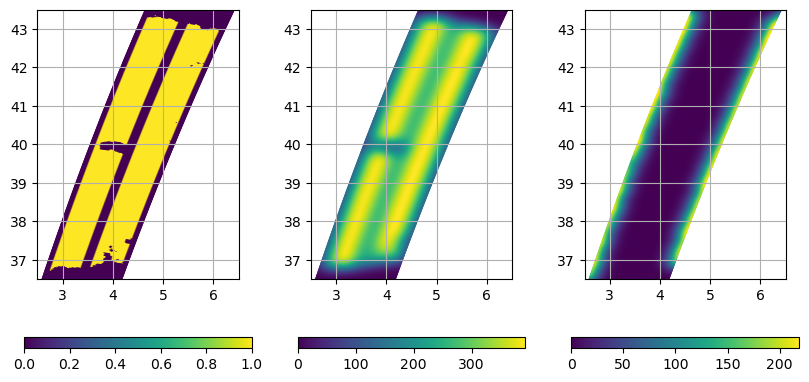

In [53]:
fig, axes = plt.subplots(1,3,figsize=(10,5))

kw = dict(vmin=-.25, vmax=.25, cmap="RdBu")
xlims, ylims = (2.5,6.5), (36.5,43.5)

da = swot["mask"]
ax = axes[0]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf["weight0"]
ax = axes[1]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

da = daf_aviso["weight1"]
ax = axes[2]
im = ax.scatter(da.longitude, da.latitude, c=da, s=1)
ax.set_aspect(np.cos(np.deg2rad(40)))
plt.colorbar(im, location="bottom")
ax.set_xlim(xlims)
ax.set_ylim(ylims)
ax.grid()

## !! units: dx, sigma, doivent être en metre ou sinon il faut ajuster code